# Matemáticas aplicadas. Parcial 1

#### Samuel Acosta ... -
#### Manuela Caro Villada - 1000124254
#### Jeronimo Velasquez Escobar - 1000116682

##### Análisis Teórico (El valor de α)

In [197]:
import sympy as sp
import numpy as np

# Definir símbolo
alpha = sp.symbols('alpha')

# Definir matriz A simbólica
A = sp.Matrix([
    [1, 2, 1],
    [alpha, 4, 1],
    [2, 1, 3]
])

# Calcular determinante simbólico
det_A = A.det()

# Resolver ecuación det(A) = 15
alpha_solution = sp.solve(det_A - 15, alpha)

alpha_solution
matriz_A = A.subs(alpha, alpha_solution[0])

determinante_A = matriz_A.det()
# Verificamos si el determinarnte coincide con el valor esperado
print(f"Determinante de A: {determinante_A}, ya habieendo remplazado el valor de alpha: {alpha_solution[0]}")
matriz_A


Determinante de A: 15, ya habieendo remplazado el valor de alpha: -8/5


Matrix([
[   1, 2, 1],
[-8/5, 4, 1],
[   2, 1, 3]])

Se calcula el determinante de la matriz A, obteniendo det(A)=7−5α. Dado que la transformación preserva la orientación y escala el volumen por un factor de 15, se impone la condición det(A)=15. Al resolver la ecuación 7−5α=15 se obtiene α=−8/5. Este valor garantiza que la matriz sea invertible y permite recuperar el mensaje original.

In [198]:
inversA = matriz_A.inv()
print("Inversa de A:")
inversA

Inversa de A:


Matrix([
[ 11/15, -1/3,  -2/15],
[ 34/75, 1/15, -13/75],
[-16/25,  1/5,  12/25]])

In [199]:
# Definimos los vectores interceptados

y_vectors = [
    sp.Matrix([74, 114, 113]),
    sp.Matrix([89, 118, 123]),
    sp.Matrix([118, 148, 186]),
    sp.Matrix([58, 88, 106]),
    sp.Matrix([128, 191, 156]),
    sp.Matrix([121, 166, 177])
]
print(y_vectors)


[Matrix([
[ 74],
[114],
[113]]), Matrix([
[ 89],
[118],
[123]]), Matrix([
[118],
[148],
[186]]), Matrix([
[ 58],
[ 88],
[106]]), Matrix([
[128],
[191],
[156]]), Matrix([
[121],
[166],
[177]])]


In [200]:
alphabet = {
    1:"A", 2:"B", 3:"C", 4:"D", 5:"E", 6:"F", 7:"G", 8:"H", 9:"I", 10:"J",
    11:"K", 12:"L", 13:"M", 14:"N", 15:"O", 16:"P", 17:"Q", 18:"R", 19:"S", 20:"T",
    21:"U", 22:"V", 23:"W", 24:"X", 25:"Y", 26:"Z", 27:" "
}


In [201]:
print("Resultados de A^-1 * y:")
def convertir(vec):
    letras = ""
    for n in vec:
        num = int(round(float(n)))
        letras += alphabet.get(num, "?")
    return letras

for i, y in enumerate(y_vectors, 1):
    x = inversA * y
    print(f"\nVector x{i}:")
    print(x)

    texto = convertir(x)
    print("Texto:", texto)

Resultados de A^-1 * y:

Vector x1:
Matrix([[6/5], [539/25], [742/25]])
Texto: AV?

Vector x2:
Matrix([[143/15], [2017/75], [642/25]])
Texto: J Z

Vector x3:
Matrix([[62/5], [778/25], [1084/25]])
Texto: L??

Vector x4:
Matrix([[-14/15], [1034/75], [784/25]])
Texto: ?N?

Vector x5:
Matrix([[47/5], [1093/25], [779/25]])
Texto: I??

Vector x6:
Matrix([[49/5], [881/25], [1018/25]])
Texto: J??


## Ejercicio Numero 2

Modelacion de satisfacciones

In [225]:
estados = {
    1:(1,2),
    2:(2,3,1),
    3:(3,2,4),
    4:(4,5,3),
    5:(5,4,6),
    6:(7,6,5),
    7:(6,7)}





matriz_de_dezplazamiento = sp.Matrix([[0, 0.95, 0.05],
                                  [0.4, 0.3, 0.3],
                                  [0.45, 0.10, 0.45],
                                  [0.4, 0.2 , 0.4],
                                  [0.45, 0.1, 0.45],
                                  [0.3, 0.3, 0.4],
                                  [0.05, 0.95, 0.0]])
matriz_de_transicion = np.array([

    [0.95, 0.05, 0,    0,    0,    0,    0],
    [0.40, 0.30, 0.30, 0,    0,    0,    0],
    [0,    0.45, 0.10, 0.45, 0,    0,    0],
    [0,    0,    0.40, 0.20, 0.40, 0,    0],
    [0,    0,    0,    0.45, 0.10, 0.45, 0],
    [0,    0,    0,    0,    0.30, 0.30, 0.40],
    [0,    0,    0,    0,    0,    0.05, 0.95]

])
matriz_de_dezplazamiento


Matrix([
[   0, 0.95, 0.05],
[ 0.4,  0.3,  0.3],
[0.45,  0.1, 0.45],
[ 0.4,  0.2,  0.4],
[0.45,  0.1, 0.45],
[ 0.3,  0.3,  0.4],
[0.05, 0.95,  0.0]])

### Simulacion


In [ ]:
import random as rnd
iteraciones = 0
recorridos = []
distribucion = []
while iteraciones < 1000:
    cantidad_de_veces_visitado = {i:0 for i in range(1,8)}

    estado = 4
    contador = 0
    recorrido = []



    while contador < 1000:

        tirada = rnd.random()
        probs = matriz_de_dezplazamiento.row(estado-1)

        regresar = probs[0]
        permanecer = probs[1]
        avanzar = probs[2]

        # Estados frontera
        if estado == 1:

            if tirada < permanecer:
                pass
            else:
                estado = 2

        elif estado == 7:

            if tirada < regresar:
                estado = 6
            else:
                pass

        # Estados intermedios
        else:

            if tirada < regresar:
                estado -= 1

            elif tirada < regresar + permanecer:
                pass

            else:
                estado += 1

        recorrido.append(estado)
        contador += 1
        cantidad_de_veces_visitado[estado] += 1


    print("\nCantidad de veces visitado cada estado:")
    for e,c in cantidad_de_veces_visitado.items():
        print(f"Estado {e}: {c}")
    
    recorridos.append(recorrido)
    distribucion.append(cantidad_de_veces_visitado)
    iteraciones += 1
    


Cantidad de veces visitado cada estado:
Estado 1: 501
Estado 2: 72
Estado 3: 58
Estado 4: 47
Estado 5: 29
Estado 6: 36
Estado 7: 257

Cantidad de veces visitado cada estado:
Estado 1: 682
Estado 2: 72
Estado 3: 38
Estado 4: 31
Estado 5: 19
Estado 6: 21
Estado 7: 137

Cantidad de veces visitado cada estado:
Estado 1: 536
Estado 2: 97
Estado 3: 54
Estado 4: 62
Estado 5: 42
Estado 6: 51
Estado 7: 158

Cantidad de veces visitado cada estado:
Estado 1: 363
Estado 2: 70
Estado 3: 58
Estado 4: 53
Estado 5: 37
Estado 6: 38
Estado 7: 381

Cantidad de veces visitado cada estado:
Estado 1: 594
Estado 2: 54
Estado 3: 25
Estado 4: 28
Estado 5: 19
Estado 6: 39
Estado 7: 241

Cantidad de veces visitado cada estado:
Estado 1: 784
Estado 2: 88
Estado 3: 35
Estado 4: 26
Estado 5: 17
Estado 6: 12
Estado 7: 38

Cantidad de veces visitado cada estado:
Estado 1: 315
Estado 2: 37
Estado 3: 29
Estado 4: 39
Estado 5: 54
Estado 6: 79
Estado 7: 447

Cantidad de veces visitado cada estado:
Estado 1: 654
Estado 2

In [216]:
finales = [rec[-1] for rec in recorridos]

from collections import Counter
conteo_final = Counter(finales)

print("Estados finales:")
for estado, conteo in conteo_final.items():
    print(f"Estado {estado}: {conteo/iteraciones}")

Estados finales:
Estado 1: 0.39
Estado 7: 0.429
Estado 2: 0.053
Estado 3: 0.032
Estado 5: 0.028
Estado 6: 0.04
Estado 4: 0.028


### Forma algebraica pura


In [227]:
p0 = np.array([0,0,0,1,0,0,0])
pn = p0.copy()

for i in range(100):
    pn =  pn @ matriz_de_transicion

print("Distribución final:")
print(pn)


Distribución final:
[0.39834023 0.04979254 0.03319503 0.03734441 0.03319503 0.04979254
 0.39834023]


De esta forma es facil ver la distribucion matematica que sigue esta matriz. Ademas nos damos cuenta que es completamente simetrica. Por ultimo es bueno añadir quee estos resultados concuerdan con los resultados obtenidos por las simulaciones.

## Tareas

1 y 2. Tendencias observadas: Se realizaron 1000 iteraciones en la simulacion de el deesplazamiento entre estados al cabo de 1000 pasos, se obseerva una distribucion uniforme en al calcular el promedio de los estados finales

In [217]:
import numpy as np

promedio = {i:0 for i in range(1,8)}

for d in distribucion:
    for k in d:
        promedio[k] += d[k]

# Dividir por número de simulaciones
n = len(distribucion)

for k in promedio:
    promedio[k] /= n

print("Distribución promedio:")
for k,v in promedio.items():
    print(f"Estado {k}: {v:.2f}")


Distribución promedio:
Estado 1: 389.36
Estado 2: 49.67
Estado 3: 34.23
Estado 4: 38.85
Estado 5: 34.80
Estado 6: 51.16
Estado 7: 401.94


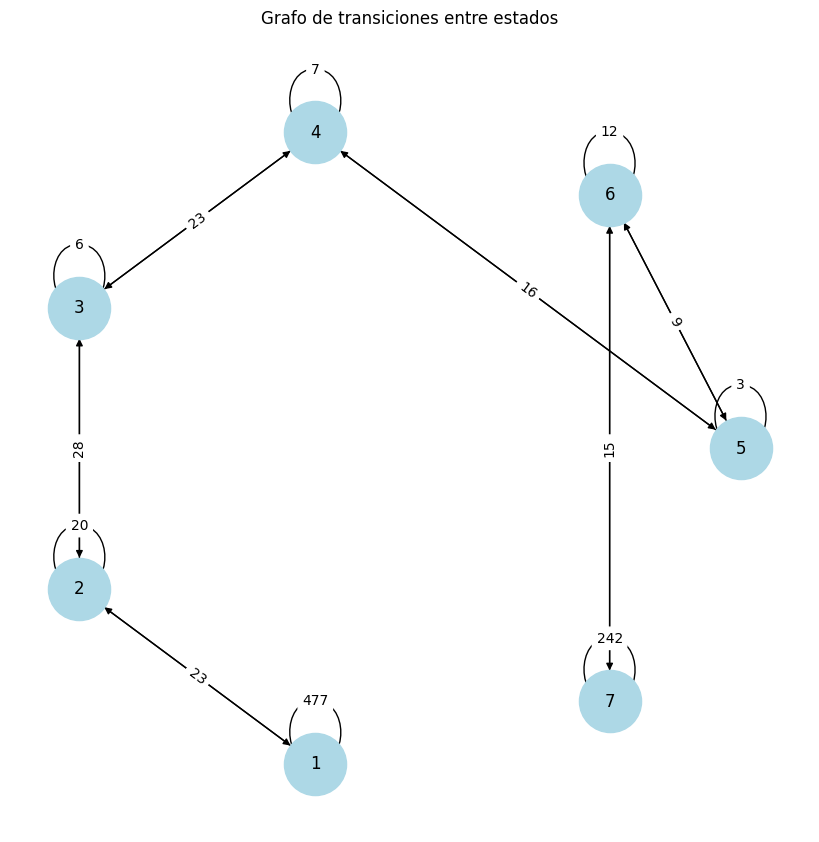

In [219]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

# Tomamos una trayectoria (por ejemplo la primera)
trayectoria = recorridos[0]

# Contar transiciones
transiciones = defaultdict(int)

for i in range(len(trayectoria)-1):
    a = trayectoria[i]
    b = trayectoria[i+1]
    transiciones[(a,b)] += 1


# Crear grafo
G = nx.DiGraph()

for (a,b),peso in transiciones.items():
    G.add_edge(a, b, weight=peso)


# Dibujar
pos = nx.circular_layout(G)

plt.figure(figsize=(8,8))

nx.draw(
    G, pos,
    with_labels=True,
    node_size=2000,
    node_color="lightblue",
    font_size=12,
    arrows=True
)

# Mostrar pesos
labels = nx.get_edge_attributes(G,'weight')
nx.draw_networkx_edge_labels(G,pos,edge_labels=labels)

plt.title("Grafo de transiciones entre estados")
plt.show()


3. En el grafo anterior observamos el reecorrido que se obtuvo eeen una simulacion en la cual se  dieron 1000 pasos, los numeros que see ven en las uniones de los estados son la cantidad de veces que ese movimeinto ocurrio en la iteracion y nuevamente se ve una concentración en los estados 7 y 1, como eencontramos en las simulaciones.

4. El sistema se modeló como una cadena de Markov homogénea con matriz de transición P. La evolución está dada por pₙ = p₀Pⁿ. Al calcular Pⁿ para n grande, se obtuvo convergencia a una distribución estacionaria π, la cual corresponde al autovector asociado al autovalor 1. Esta distribución fue validada mediante simulaciones Monte Carlo.

## Ejercicio 3